# Phase 7 

### chargement de la dataset 

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam, SGD


data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("\nRépartition des classes :")
print(y.value_counts(normalize=True).sort_index().round(3))


Répartition des classes :
target
0    0.373
1    0.627
Name: proportion, dtype: float64


### Coût métier

#### Fonction de coût métier

In [18]:
def cout_metier_cancer(y_true, y_pred, cout_maligne_ratee=10, cout_fausse_alerte=1):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    malignes_ratees = np.sum((y_true == 0) & (y_pred == 1))
    fausses_alertes = np.sum((y_true == 1) & (y_pred == 0))

    cout_total = (malignes_ratees * cout_maligne_ratee + fausses_alertes * cout_fausse_alerte)

    return cout_total

### Fonction d’évaluation

#### Fonction métriques

In [13]:
def calculer_metriques(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)

    precision_maligne = precision_score(y_true,y_pred,pos_label=0,zero_division=0)

    recall_maligne = recall_score(y_true,y_pred,pos_label=0,zero_division=0)

    f1_maligne = f1_score(y_true,y_pred,pos_label=0,zero_division=0)

    cout = cout_metier_cancer(y_true, y_pred)

    return {"accuracy": accuracy,"precision_maligne": precision_maligne,"recall_maligne": recall_maligne,"f1_maligne": f1_maligne,"cout_metier": cout
    }

### Fonction validation croisée modèles classiques

In [6]:
def evaluer_modele_classique_cv(nom_modele, modele, X, y, k=3):
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    resultats = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        modele_fold = clone(modele)

        debut_train = time.perf_counter()
        modele_fold.fit(X_train, y_train)
        fin_train = time.perf_counter()

        debut_pred = time.perf_counter()
        y_pred = modele_fold.predict(X_test)
        fin_pred = time.perf_counter()

        metriques = calculer_metriques(y_test, y_pred)

        metriques["modele"] = nom_modele
        metriques["fold"] = fold
        metriques["temps_entrainement"] = fin_train - debut_train
        metriques["latence_prediction_ms"] = ((fin_pred - debut_pred) / len(X_test)) * 1000

        resultats.append(metriques)

    return pd.DataFrame(resultats)

#### Évaluer Random Forest/Gradient Boosting

In [12]:
modeles_classiques = {
    "RandomForest": RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)}

resultats_classiques = []

for nom, modele in modeles_classiques.items():
    resultat = evaluer_modele_classique_cv(nom_modele=nom,modele=modele,X=X,y=y,k=3)

    resultats_classiques.append(resultat)

resultats_classiques = pd.concat(resultats_classiques, ignore_index=True)

display(resultats_classiques)

,accuracy,precision_maligne,recall_maligne,f1_maligne,cout_metier,modele,fold,temps_entrainement,latence_prediction_ms
0,0.968421,0.945205,0.971831,0.958333,24,RandomForest,1,0.254502,0.022118
1,0.926316,0.952381,0.845070,0.895522,113,RandomForest,2,0.208924,0.030066
2,0.968254,0.944444,0.971429,0.957746,24,RandomForest,3,0.276320,0.021675
3,0.968421,0.957746,0.957746,0.957746,33,GradientBoosting,1,0.332988,0.008546
4,0.926316,0.983051,0.816901,0.892308,131,GradientBoosting,2,0.368422,0.004427
5,0.962963,0.931507,0.971429,0.951049,25,GradientBoosting,3,0.360754,0.004594


#### Tableau résumé modèles classiques

In [10]:
resume_classiques = (
    resultats_classiques
    .groupby("modele")
    .agg(
        accuracy_moyenne=("accuracy", "mean"),
        recall_maligne_moyen=("recall_maligne", "mean"),
        f1_maligne_moyen=("f1_maligne", "mean"),
        cout_metier_moyen=("cout_metier", "mean"),
        temps_entrainement_moyen=("temps_entrainement", "mean"),
        latence_prediction_ms_moyenne=("latence_prediction_ms", "mean")
    )
    .reset_index()
)

display(resume_classiques.sort_values("cout_metier_moyen"))

,modele,accuracy_moyenne,recall_maligne_moyen,f1_maligne_moyen,cout_metier_moyen,temps_entrainement_moyen,latence_prediction_ms_moyenne
1,RandomForest,0.954330,0.929443,0.937201,53.666667,0.233652,0.026347
0,GradientBoosting,0.952567,0.915359,0.933701,63.000000,0.343633,0.004401


### PMC Keras

In [19]:
def creer_pmc(n_features, optimiseur="adam"):
    

    tf.keras.utils.set_random_seed(42)

    if optimiseur == "adam":
        opt = Adam(learning_rate=0.001)
    elif optimiseur == "sgd":
        opt = SGD(learning_rate=0.01)
    else:
        raise ValueError("Optimiseur inconnu. Utiliser 'adam' ou 'sgd'.")

    modele = Sequential([
        Input(shape=(n_features,)),
        Dense(16, activation="relu"),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    modele.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return modele

### Validation croisée du PMC

#### Fonction validation croisée PMC et l'Évaluer avec Adam

In [21]:
def evaluer_pmc_cv(X, y, optimiseur="adam", k=3, epochs=30):
    cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    resultats = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        scaler = StandardScaler()

        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        modele = creer_pmc(n_features=X_train_scaled.shape[1],optimiseur=optimiseur)

        debut_train = time.perf_counter()

        modele.fit(X_train_scaled,y_train,epochs=epochs,batch_size=32,verbose=0)

        fin_train = time.perf_counter()

        debut_pred = time.perf_counter()

        proba = modele.predict(X_test_scaled,verbose=0).ravel()

        y_pred = (proba >= 0.5).astype(int)

        fin_pred = time.perf_counter()

        metriques = calculer_metriques(y_test, y_pred)

        metriques["modele"] = f"PMC_Keras_{optimiseur.upper()}"
        metriques["fold"] = fold
        metriques["temps_entrainement"] = fin_train - debut_train
        metriques["latence_prediction_ms"] = ((fin_pred - debut_pred) / len(X_test)) * 1000

        resultats.append(metriques)

    return pd.DataFrame(resultats)
resultats_pmc_adam = evaluer_pmc_cv(X=X,y=y,optimiseur="adam",k=3,epochs=30)

display(resultats_pmc_adam)

,accuracy,precision_maligne,recall_maligne,f1_maligne,cout_metier,modele,fold,temps_entrainement,latence_prediction_ms
0,0.984211,0.972222,0.985915,0.979021,12,PMC_Keras_ADAM,1,1.877404,0.573134
1,0.942105,0.983871,0.859155,0.917293,101,PMC_Keras_ADAM,2,1.729015,0.536318
2,0.984127,0.971831,0.985714,0.978723,12,PMC_Keras_ADAM,3,1.820587,0.481421


### Comparaison SGD vs Adam

#### train / validation pour SGD vs Adam

In [23]:
X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

scaler_comp = StandardScaler()

X_train_scaled = scaler_comp.fit_transform(X_train)
X_val_scaled = scaler_comp.transform(X_val)
print("Validation :", X_val_scaled.shape)

Validation : (114, 30)


#### Entraîner PMC avec SGD et Adam

In [25]:
pmc_sgd = creer_pmc(n_features=X_train_scaled.shape[1],optimiseur="sgd")

history_sgd = pmc_sgd.fit(X_train_scaled,y_train,validation_data=(X_val_scaled, y_val),epochs=40,batch_size=32,verbose=0)

pmc_adam = creer_pmc(n_features=X_train_scaled.shape[1],optimiseur="adam")

history_adam = pmc_adam.fit(X_train_scaled,y_train,validation_data=(X_val_scaled, y_val),epochs=40,batch_size=32,verbose=0)
print("Entraînement SGD terminé.")
print("Entraînement Adam terminé.")


Entraînement SGD terminé.
Entraînement Adam terminé.


#### Tracer les courbes de loss

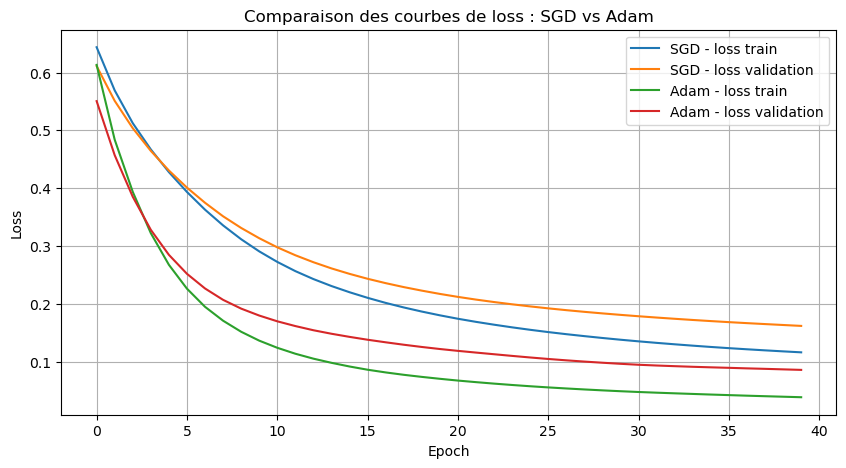

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(history_sgd.history["loss"], label="SGD - loss train")
plt.plot(history_sgd.history["val_loss"], label="SGD - loss validation")
plt.plot(history_adam.history["loss"], label="Adam - loss train")
plt.plot(history_adam.history["val_loss"], label="Adam - loss validation")

plt.title("Comparaison des courbes de loss : SGD vs Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

### Latence de l’API

#### Mesurer la latence de l’API Flask

In [31]:
def mesurer_latence_api(url="http://127.0.0.1:5000/predict", n_requetes=10):
    try:
        import requests
    except ImportError:
        print("La librairie requests n'est pas installée.")
        return None

    features_exemple = X.iloc[0].tolist()

    temps_requetes = []

    for _ in range(n_requetes):
        debut = time.perf_counter()

        try:
            reponse = requests.post(
                url,
                json={"features": features_exemple},
                timeout=5
            )

            fin = time.perf_counter()

            if reponse.status_code == 200:
                temps_requetes.append(fin - debut)
            else:
                print("Réponse API non valide :", reponse.status_code)
                return None

        except Exception as erreur:
            print("API non lancée ou inaccessible.")
            print("Détail :", erreur)
            return None

    latence_moyenne_ms = np.mean(temps_requetes) * 1000

    print(f"Latence moyenne API : {latence_moyenne_ms:.2f} ms")

    return latence_moyenne_ms
latence_api_ms = mesurer_latence_api()

latence_api_ms

Latence moyenne API : 8.70 ms


np.float64(8.704419998684898)

#### Construire le leaderboard 

In [29]:
resultats_tous_modeles = pd.concat(
    [resultats_classiques,resultats_pmc_adam],
    ignore_index=True)

leaderboard = (resultats_tous_modeles.groupby("modele").agg(
        accuracy_moyenne=("accuracy", "mean"),
        precision_maligne_moyenne=("precision_maligne", "mean"),
        recall_maligne_moyen=("recall_maligne", "mean"),
        f1_maligne_moyen=("f1_maligne", "mean"),
        cout_metier_moyen=("cout_metier", "mean"),
        temps_entrainement_moyen=("temps_entrainement", "mean"),
        latence_prediction_ms_moyenne=("latence_prediction_ms", "mean")).reset_index())

leaderboard = leaderboard.sort_values(
    by=["cout_metier_moyen","recall_maligne_moyen","accuracy_moyenne"],ascending=[True,False,False])

display(leaderboard)

,modele,accuracy_moyenne,precision_maligne_moyenne,recall_maligne_moyen,f1_maligne_moyen,cout_metier_moyen,temps_entrainement_moyen,latence_prediction_ms_moyenne
1,PMC_Keras_ADAM,0.970148,0.975975,0.943595,0.958346,41.666667,1.809002,0.530291
2,RandomForest,0.954330,0.947344,0.929443,0.937201,53.666667,0.246582,0.024620
0,GradientBoosting,0.952567,0.957435,0.915359,0.933701,63.000000,0.354055,0.005856


#### Choisir le champion

In [30]:
champion = leaderboard.iloc[0]

print("Champion final :")
print(champion["modele"])

print("\nRésumé du champion :")
print(f"Accuracy moyenne : {champion['accuracy_moyenne']:.3f}")
print(f"Recall classe maligne : {champion['recall_maligne_moyen']:.3f}")
print(f"F1 classe maligne : {champion['f1_maligne_moyen']:.3f}")
print(f"Coût métier moyen : {champion['cout_metier_moyen']:.2f}")
print(f"Temps entraînement moyen : {champion['temps_entrainement_moyen']:.3f} s")
print(f"Latence prédiction moyenne : {champion['latence_prediction_ms_moyenne']:.3f} ms")

Champion final :
PMC_Keras_ADAM

Résumé du champion :
Accuracy moyenne : 0.970
Recall classe maligne : 0.944
F1 classe maligne : 0.958
Coût métier moyen : 41.67
Temps entraînement moyen : 1.809 s
Latence prédiction moyenne : 0.530 ms
